---
# Classification and Regression with Artificial Neural Networks using Keras
---

Attribution:
- This notebook has been adapted from the book [Hands-on Machine Learning with Scikit-Learn, Keras and TensorFlow by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781098125967) and its associated [GitHub Repository](https://github.com/ageron/handson-ml3).

This notebook covers:
- Loading and preprocessing datasets.
- Building, training, and evaluating classification models using Keras.
- Building, training, and evaluating regression models using Keras.
- Hyperparameter tuning using Keras Tuner.

This notebook contains the following sections:
- [1. Prerequisites](#1-prerequisites) which covers setting up the environment.
- [2. Image Preprocessing and Classification](#2-image-preprocessing-and-classification) which introduces basic image preprocessing and classification concepts.
- [3. Loading Images from Disk and Preprocessing Them](#3-loading-images-from-disk-and-preprocessing-them) which covers loading and preprocessing images.
- [4. Building, Training, and Evaluating a Classification Model Using the Sequential API](#4-building-training-and-evaluating-a-classification-model-using-the-sequential-api) which covers creating, training, and evaluating a classification model.
- [5. Fine-Tuning Neural Network Hyperparameters with Keras Tuner](#5-fine-tuning-neural-network-hyperparameters-with-keras-tuner) which demonstrates using the Keras Tuner to fine-tune hyperparameters.
- [6. Building, Training, and Evaluating a Regression Model Using the Sequential API](#6-building-training-and-evaluating-a-regression-model-using-the-sequential-api) which covers creating, training, and evaluating a regression model.

**Note!**
- You need to download the following dataset from Canvas and place it in the `notebook/datasets` folder before you can use this notebook.
  - `cifar10.zip`
- The following datasets, also on Canvas, are optional (place them in the `notebook/datasets` folder if you download them).
  - `fashion_mnist.zip`
  - `flower_photos.zip`
  - `mnist.zip`
  - `traffic_signs.zip`

---
## 1. Prerequisites

### Dataset

Make sure you have downloaded the `cifar10.zip` dataset from Canvas and placed it in the `notebooks/datasets` folder.

### Software

Make sure you have installed the following software on your computer:

- [Visual Studio Code](https://code.visualstudio.com)
- [Git](https://git-scm.com/downloads)
- [Miniconda](https://docs.anaconda.com/miniconda/install/#quick-command-line-install)
- [Python](https://www.python.org) (optional) - comes pre-installed on Linux and Mac
- [Graphviz](https://graphviz.gitlab.io/download)

### Visual Studio Code (VSCode) Extensions

Also make sure you have installed the necessary Visual Studio Code Extensions:

```bash
code --install-extension ms-toolsai.jupyter
code --install-extension ms-python.python
```

### Python Virtual Environment

Finally, make sure you have created a Python virtual environment as below (and selected it as the kernel in the top right of this notebook):

```bash
git clone https://github.com/paga-hb/C1TM1B_2026.git ml
cd ml
conda create -y -p ./.conda python=3.12
conda activate ./.conda
python -m pip install --upgrade pip
pip install ipykernel jupyter numpy pandas matplotlib pydot scikit-learn tensorflow keras_tuner

```

### Python Package Imports

Let's start by importing the python packages we will be using.

- **Note: this jupyter notebook uses *Graphviz* to "plot" keras models**
  - If *graphviz* isn't installed on your computer, just skip the notebook cells that plot models, i.e. that use `keras.utils.plot_model()`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os

# Let's assume no GPU is available (at least for this workshop)
# These two lines have to be executed before importing tensorflow
# If you have a (properly configured) GPU, you can comment out these lines
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # disable GPU
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # disable Tensorflow C++ log messages

import shutil
from pathlib import Path
from zipfile import ZipFile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Let's print out if Tensorflow has detected a GPU
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: []


### We'll configure Matplotlib with default font sizes for our figures

In [2]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### We'll also create a function `save_fig()` to save all our figures into the folder `figures`

In [3]:
IMAGES_PATH = Path() / "figures"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

---
## 2. Image Preprocessing and Classification

One important task within artificial intelligence is using machine learning techniques for **classifying images**. Datasets of images are somewhat different to traditional tabular datasets with rows (data points) and columns (features/attributes) often found in text files, CSV files, or relational databases.

Just as a data point (sample) in a traditional dataset can be multi-dimensional (i.e. have multiple features/attributes), an image sample is multi-dimensional in the sense that it has multiple pixels. Additionally, an image has **spatial structure** associated with it, consisting of a two-dimensional array of pixels (rows and columns), where each pixel usually has three color channels (red, green and blue). With an **8-bit color depth**, each **pixel has a value in the range 0 - 255** in each of the three **color channels (red, green, blue)**. Therefore, a color image actually has a three-dimensional structure, where the first two dimensions are the rows (height) and columns (width), and the third dimension is the three color channels stacked on top of each other. Such images are refered to as RGB (red, green, blue) images. Some images also have a fourth channel - an *alpha* channel - that decides the transparancy/opaqueness of each pixel, and are refered to as RGBA (red, green, blue, alpha) images.

<div style="display: flex; justify-content: space-between: 5px; margin: 20px;">
    <table style="border-collapse: collapse; width: 15%; margin-right: 10px; color: red; float: left; clear: left;">
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
    </table>
    <table style="border-collapse: collapse; width: 15%; margin-right: 10px; color: green;">
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
    </table>
    <table style="border-collapse: collapse; width: 15%; margin-right: 10px; color: blue;">
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
    </table>
</div>

A color image can be converted into a **grayscale image**, where the image colapses into a two-dimensional structure consisting of rows (height) and columns (width) and a **single grayscale color channel**, where each **pixel has a value between 0 (black) and 255 (white)** using an **8-bit color depth**.

<div style="display: flex; justify-content: space-between: 5px; margin: 20px;">
    <table style="border-collapse: collapse; width: 15%; margin-right: 10px; color: #D97706; float: left; clear: left;">
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
        </tr>
        <tr>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="25px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
    </table>
</div>

Therefore, the grayscale image above actually represents a white letter **X** as shown below.

<div style="display: flex; justify-content: space-between: 5px; margin: 20px;">
    <table style="table-layout: fixed; border-collapse: collapse; color: #D97706;">
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
        </tr>
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
        </tr>
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
        </tr>
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
        </tr>
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="black"></td>
            <td width="28px" height="40px" align="middle" vertical-align="middle" bgcolor="white"></td>
        </tr>
    </table>
</div>

If we convert a color image into a grayscale image, and then **flatten** it, we get something that resembles a traditional data point with a number of features/attributes (pixels). When **flattening an image**, we just place each row after each other.

<div style="display: flex; justify-content: space-between: 5px; margin: 20px;">
    <table style="table-layout: fixed; border-collapse: collapse; color: #D97706;">
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">255</td>
        </tr>
    </table>
</div>

Lastly, we can **normalize** the image by **rescaling the pixel values to floats between 0 and 1.0** (i.e. we simply divide each pixel value with 255.0).

<div style="display: flex; justify-content: space-between: 5px; margin: 20px;">
    <table style="table-layout: fixed; border-collapse: collapse; color: #D97706;">
        <tr>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">0</td>
            <td width="28px" height="40px" align="middle" vertical-align="middle">1.0</td>
        </tr>
    </table>
</div>

Now we see that the original 5x5, 8-bit color image has been reduced to a data point with 25 features/attributes (pixels with values between 0 and 1.0), and we already know how to work with such data using traditional machine learning algorithms.

In this workshop, we will carry-out the pre-processing steps above, to reduce color images into flattened grayscale images with normalized (rescaled) pixel values, before feeding them into a **fully-connected, feed-forward neural network**. There are other neural network architectures that work well (even better) with images without flattening them first (neural networks with **convolutional layers**), but we will **only be using fully-connected, feed-forward layers** (called `Dense` layers in Keras) in this workshop.

Keras, the high-level Tensorflow API, will be used to train neural network models for **classifying images**, i.e. if we feed an image into a trained neural network, it should output which class the image belongs to (e.g. if an image contains an object of a cat, dog or a horse, the network should output the corresponding animal class).

---
## 3. Loading Images from Disk and Preprocessing Them

### Let's creating a function `get_dataset_path()`
- The folder `datasets` contains a number of zipped datasets.
- The function `get_dataset_path()`:
  1. Takes a `dataset name` as input.
  2. Unzips the dataset.
  3. Returns the path to the unzipped dataset.

In [4]:
def get_dataset_path(dataset):

    dataset_root = os.path.join(os.getcwd(), "datasets")
    data_dir = Path(os.path.join(dataset_root, dataset))
    dataset_zip = Path(data_dir).with_suffix(".zip")

    if not data_dir.is_dir():
        with ZipFile(dataset_zip, 'r') as zip_ref:
            zip_ref.extractall(dataset_root)

    return data_dir

### We will use the `cifar10` dataset in this notebook for classification

In [5]:
dataset = "cifar10"
# dataset = "fashion_mnist"
# dataset = "flower_photos"
# dataset = "mnist"
# dataset = "traffic_signs"

data_dir = get_dataset_path(dataset)
data_dir

PosixPath('/home/patrick/projects/ml/notebooks/datasets/cifar10')

**The CIFAR10 dataset**

- The folder `datasets` now contains a subfolder `cifar10`.
- The `cifar10` subfolder (dataset) contains 10 subfolders, each containing images for a specific class.
- You should have the following folder structure: 

  ```
  datasets/
    cifar10/
      airplane/
      automobile/
      bird/
      cat/
      deer/
      dog/
      frog/
      horse/
      ship/
      truck/
  ```

- Notice that each subfolder under the `cifar10` folder is the name of a specific class (e.g. cat).
- In each subfolder, there are a number of images belonging to that class (e.g. cat images).

**Loading and preprocessing images with Keras**

- Keras has a niftly utility method `image_dataset_from_directory()` for loading images from disk.
- It has a number of parameters with default values as shown below.

  ```python
  directory # no default value
  labels='inferred'
  label_mode='int'
  class_names=None
  color_mode='rgb'
  batch_size=32
  image_size=(256, 256)
  shuffle=True
  seed=None
  validation_split=None
  subset=None
  interpolation='bilinear'
  follow_links=False
  crop_to_aspect_ratio=False
  pad_to_aspect_ratio=False
  data_format=None
  verbose=True
  ```

- You can always print the Python *docstring* for any method in a notebook cell, by adding a `?` after the method name.

In [6]:
tf.keras.utils.image_dataset_from_directory?

Signature:
tf.keras.utils.image_dataset_from_directory(
    directory,
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format='tf',
    verbose=True,
)
Docstring:
Generates a dataset from image files in a directory.

If your directory structure is:

```
main_directory/
...class_a/
......a_image_1.jpg
......a_image_2.jpg
...class_b/
......b_image_1.jpg
......b_image_2.jpg
```

Then calling `image_dataset_from_directory(main_directory,
labels='inferred')` will return a dataset that yields batches of
images from the subdirectories `class_a` and `class_b`, together with labels
0 and 1 (0 corresponding to `class_a` and 1 corresponding to `class_b`).

Supported image formats: `.jpeg`, `.jpg

**Loading all images in a folder and all its subfolders**

- The code below loads all images under the chosen dataset folder into the variable `full_ds` (full dataset).
- Notice the settings below:
  - `color_mode = 'rgb'`: reads the images as color images, i.e. does not automatically convert them into grayscale.
  - `batch_size = 32`: the images are automatically partitioned (subdivided) into batches of `32` images each.
  - `image_size = (180, 180) # (height, width)`: the images are automatically rescaled so that each image is `180x180` pixels (height, width).
  - `seed=123`: seeds a psuedo-random number generator with seed `123`, so that any randomization can be recreated (e.g. the images are shuffled by default).
  - `validation_split=None`: the images are not split into a validation set and a training set (all images are loaded into `full_ds`).
  - `subset=None`: this setting is only used when `validation_split` is set to something other than `None`. 

- Notice the message in the output below, telling us how many files (images) were found, and how many different classes there are.
- The classnames are infered from the names of the subfolders, i.e. if an image is in a folder called `dog`, then the image belongs to the `dog` class.

In [7]:
color_mode = 'rgb'
batch_size = 32
image_size = (28, 28) # (height, width)
seed=123
validation_split=None
subset=None

full_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir,
    color_mode=color_mode,
    batch_size=batch_size,
    image_size=image_size,
    seed=seed,
    validation_split=validation_split,
    subset=subset
)

Found 60000 files belonging to 10 classes.


**Getting the class names from the loaded dataset**

- With these settings, the class names are stored in the `class_names` property.
  - As mentioned above, the class names are automatically infered from the subfolder names.

In [8]:
class_names = full_ds.class_names
print(f'Class names: {class_names}')

num_classes = len(class_names)
print(f'\nNumber of classes: {num_classes}')

Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Number of classes: 10


**Plotting sample images from the loaded dataset**

- The code below calls the `take(1)` method on the loaded dataset, which returns the first batch.
- Each batch contains the images (features) and the corresponding labels (classes),  i.e. the equivalent of `X_train` and `y_train` in the course book.
- By indexing into the array of images (features), and using matplotlib, the image can be plotted.
- Also notice how the associated classname is extracted and used as a title.

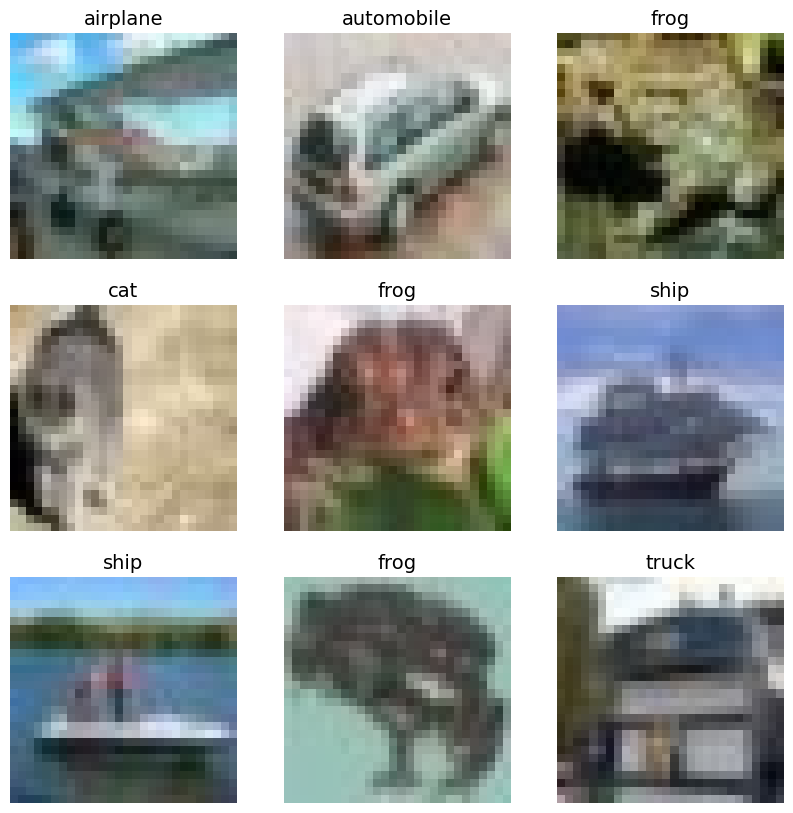

In [9]:
plt.figure(figsize=(10, 10))

for images, labels in full_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

**Loading a training set (split) from all images in a folder and its subfolders**

- The code above is great if we want to load ALL images from a folder (including its subfolders).
- Even better, is if we split the loaded dataset into a **traning set** and a **validation set**.
- Furthermore, we want to covert the images into **grayscale**.
- The important settings here are:
  - `color_mode = 'grayscale'`: reads the images (in this case color images), and automatically converts them into **grayscale** images.
  - `batch_size = 32`: the images are automatically partitioned into batches of `32` images.
  - `image_size = (28, 28) # (height, width)`: the images are automatically rescaled so that each image is `28x28` pixels (height, width).
  - `seed=123`: seeds a psuedo-random number generator with seed `123`, so that any randomization can be recreated (e.g. the images are shuffled by default).
  - `validation_split=0.3`: the **images are split** into a **traing set** and a **validation set** (70% to the traning set, 30% to the validation set).
  - `subset="training"`: **returns the traning set** from the `validation_split`.

- From the settings above, we see that we obtain a training set consisting of 70% of the images, where the images are guaranteed to be in grayscale.
- The traning set is stored in the variable `train_ds`.

In [10]:
color_mode = 'grayscale'
batch_size = 32
seed=123
validation_split=0.3
subset="training"

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir,
    color_mode=color_mode,
    batch_size=batch_size,
    image_size=image_size,
    seed=seed,
    validation_split=validation_split,
    subset=subset
)

Found 60000 files belonging to 10 classes.
Using 42000 files for training.


**Loading the validation split**

- Now, we keep the exact same settings, except for the following setting:
  - `subset="validation"`: returns the **validation set** from the `validation_split`.
- Note, it's important to **keep the same values for the other settings**.
- From these settings, we see that we obtain a validation set consisting of 30% of the images, where the images are guaranteed to be in grayscale.
- The validation set is stored in the variable `val_ds`.

In [11]:
color_mode = 'grayscale'
batch_size = 32
seed=123
validation_split=0.3
subset="validation"

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=data_dir,
    color_mode=color_mode,
    batch_size=batch_size,
    image_size=image_size,
    seed=seed,
    validation_split=validation_split,
    subset=subset
)

Found 60000 files belonging to 10 classes.
Using 18000 files for validation.


**Creating the test set**

- All is good and well, but what about the test set?
- Unfortunately, `image_dataset_from_directory()` doesn't provide any setting to create a three-way split (traning, validation, test).
- But we can retrieve the number of batches in e.g. the loaded validation set `val_ds`, then split these into a validation set and a test set.
- The code below:
  - Uses the `cardinality()` method to get the number of batches in the validation set `val_ds`.
  - Uses the `take()` method to "take" the first 2/3 of the batches in `val_ds` and store them in `test_ds`.
  - Uses the `skip()` method to "skip over" the first 2/3 of the batches in `val_ds` (i.e. takes the last 1/3), and stores them back into `val_ds`.
- The end result is three datasets:
  - `train_ds` contains batches of training images (each batch contains 32 images with labels).
  - `val_ds` contains batches of validation images (each batch contains 32 images with labels).
  - `test_ds` contains batches of test images (each batch contains 32 images with labels).

In [12]:
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take((2*val_batches) // 3) # 2/3 of batches to test set
val_ds = val_ds.skip((2*val_batches) // 3)  # 1/3 of batches to validation set

print(f'# train batches : {tf.data.experimental.cardinality(train_ds).numpy()}')
print(f'# val batches   : {tf.data.experimental.cardinality(val_ds).numpy()}')
print(f'# test batches  : {tf.data.experimental.cardinality(test_ds).numpy()}')

# train batches : 1313
# val batches   : 188
# test batches  : 375


**Using matplotlib to plot sample images again**

- Let's print some sample images from the first batch of `train_ds` again.
- Notice that we now have grayscale images (since we used `image_dataset_from_directory()` with `color_mode = 'grayscale'`.)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


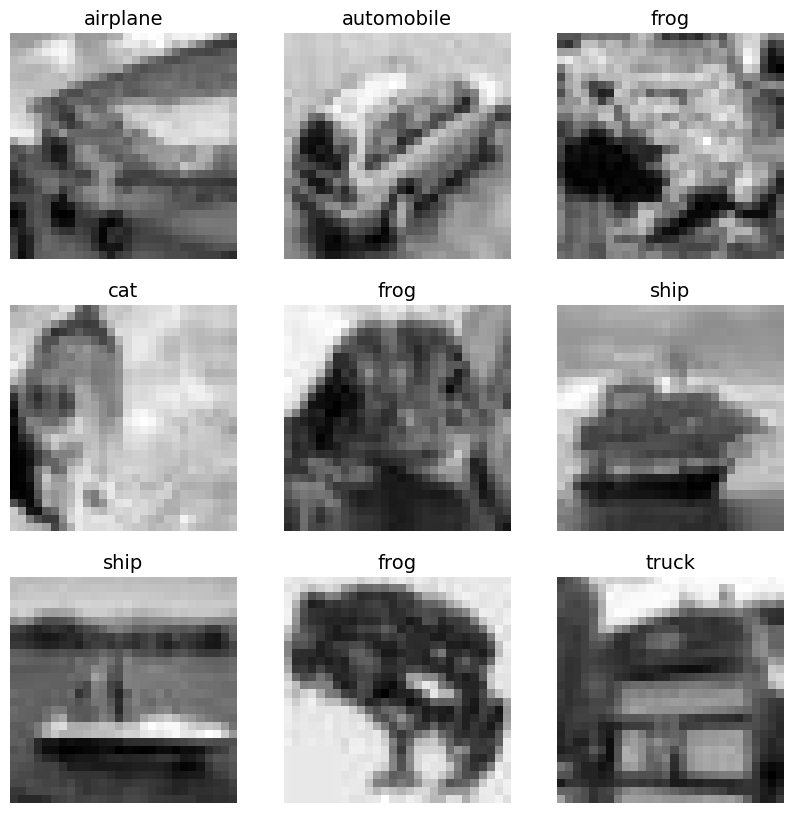

In [13]:
class_names = train_ds.class_names
print(class_names)

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"), cmap='gray')
    plt.title(class_names[labels[i]])
    plt.axis("off")

**Checking the shape of a batch**

- Let's look at the shape of one batch.
- Notice that one batch of images (features), i.e. the equivalent of `X_train` in the course book, has shape `(32, 28, 28, 1)`:
  - `32`: the batch size, i.e. each minibatch contains 32 images.
  - `28`: the first 28 is the image height, i.e. 28 rows of pixels.
  - `28`: the second 28 is the image width, i.e. 28 columns of pixels.
  - `1`: this is the one and only color channel since we have grayscale images (if we loaded color images, this would be `3` - red, green, blue).
- Notice that one batch of labels (classes), i.e. the equivalent of `y_train` in the course book, has shape `(32,)`:
  - `32`: the batch size, i.e. each minibatch contains 32 labels.

In [14]:
for image_batch, label_batch in train_ds.take(1):
  print(f'image: {image_batch.shape}')
  print(f'label: {label_batch.shape}')

image: (32, 28, 28, 1)
label: (32,)


**Checking the datatype of a batch**

- Let's also look at the datatype of one batch.
  - We see that the pixels in the images are of type `float32`.
  - We see that the labels are of type `int32`.

In [15]:
for image_batch, label_batch in train_ds.take(1):
  print(f'image: {image_batch.dtype}')
  print(f'label: {label_batch.dtype}')

image: <dtype: 'float32'>
label: <dtype: 'int32'>


**Checking the values of a batch**

- Let's also look at the values of batch.
  - We see that the pixels in the images have values between `0` and `255.0`.
  - We see that the labels have values between `0` and `9`.

In [16]:
for image_batch, label_batch in train_ds.take(1):
  print(f'image (min:{np.min(image_batch)}, max:{np.max(image_batch)}):\n{image_batch}\n')
  print(f'label (min:{np.min(label_batch)}, max:{np.max(label_batch)}):\n {label_batch}')

image (min:0.0, max:254.99490356445312):
[[[[ 26.005102]
   [ 23.979593]
   [ 24.75    ]
   ...
   [ 37.397964]
   [ 42.45919 ]
   [ 47.362255]]

  [[ 31.7449  ]
   [ 29.41837 ]
   [ 27.704082]
   ...
   [ 46.586742]
   [ 50.948982]
   [ 54.102047]]

  [[ 43.647957]
   [ 42.122448]
   [ 38.9898  ]
   ...
   [ 43.82653 ]
   [ 45.295918]
   [ 46.16837 ]]

  ...

  [[ 46.571434]
   [ 81.06121 ]
   [107.39793 ]
   ...
   [ 48.51529 ]
   [ 39.81119 ]
   [ 31.994854]]

  [[ 45.413265]
   [ 61.826515]
   [ 70.341805]
   ...
   [ 64.84185 ]
   [ 48.938778]
   [ 37.69898 ]]

  [[ 40.15815 ]
   [ 48.97957 ]
   [ 43.806076]
   ...
   [ 96.693954]
   [ 92.88274 ]
   [ 89.39297 ]]]


 [[[124.42857 ]
   [146.07143 ]
   [151.94899 ]
   ...
   [110.16832 ]
   [108.12246 ]
   [110.918365]]

  [[159.60715 ]
   [161.43367 ]
   [153.34183 ]
   ...
   [ 95.73976 ]
   [113.56126 ]
   [105.18363 ]]

  [[198.76021 ]
   [176.43367 ]
   [153.35715 ]
   ...
   [ 87.01526 ]
   [107.83677 ]
   [ 78.16318 ]]

  ...

**Preprocessing the images**

- We need to take care of some preprocessing before we can feed our images into the Keras image classifier model we will create (which will be a fully-connected, feed-forward neural network).

  1. First, we need to covert our color images into grayscale images (one color channel), which we have already taken care of above.
  2. What if the images all have different sizes, i.e. some are 180x180, others 360x100, and yet others 10x50?
     - We need to resize the images so that they all have the same height and width.
     - The `image_size=(28,28)` setting in `image_dataset_from_directory` already did some of this for us, but left us with the shape `(28, 28, 1)`.
     - We need to remove the superfluous last dimension `1`, i.e. we want our grayscale images to have shape `(28, 28)`.
     - After that, our Keras `Flatten` layer will take care of flattening the `(28, 28)` image into a one-dimensional structure `784`.
       - Note that if we were using 2D Convolutional Layers (instead of Dense Layers), we wouldn't flatten the images.
  3. Lastly, our images currently have an 8-bit color depth (i.e. values between `0` and `255.0`).
     - As we know, neural networks don't play well with unnormalized inputs, so we need to normalize (rescale) the data somehow.
     - Let's normalize (rescale) the data (images) to values between `0` and `1.0` (floats).

- In the code below, we see that we can actually do all this preprocessing using Keras layers.
- The code shows how to do this manually, using the layers outside of a model, but later we will add these layers to an actual model instead.

In [17]:
reshaping_layer = tf.keras.layers.Reshape(image_size)
rescaling_layer = tf.keras.layers.Rescaling(1./255.)

reshaped_ds = train_ds.map(lambda x, y: (reshaping_layer(x), y))
rescaled_ds = reshaped_ds.map(lambda x, y: (rescaling_layer(x), y))

image_batch, label_batch = next(iter(rescaled_ds)) # this loads one batch

print(f'Shape : {image_batch.shape}')
print(f'Min   : {np.min(image_batch)}')
print(f'Max   : {np.max(image_batch)}')

Shape : (32, 28, 28)
Min   : 0.0
Max   : 1.0


**Speeding up training by pre-fetching images from disk and caching them in RAM**

- The code below adds a final touch to our datasets.
  - By calling `cache()` on a dataset, it will cache images in RAM (i.e. avoid reading images from disk each time they are needed).
  - By calling `prefetch()` on a dataset, images will be fetched from disk (if not in the cache) and preprocessed before they are needed.
- You will notice the first epoch might take some time during traning, but the following epochs will be a lot faster.
  - This is because we called `cache()` and `prefetch()` on the datasets (traning, validation, test).

In [18]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

---
## 4. Building, Training, and Evaluating a Classification Model Using the Sequential API

Now that we have taken care of loading and preprocessing an image dataset, we will look at a full example of building, training, and evaluating an image classification model using Keras.
- Most of these concepts are from the course book, Chapters 10-11

### Building Neural Network Models with Keras

- Keras provides three different ways of building neural network architectures
  - The **Sequential model** assembles a neural network by stacking layers on top of each other (i.e. in a sequence of layers).
  - The **Functional API** assembles a neural network by calling a function on a layer instance, passing in another layer as an argument.
  - **Model subclassing** assembles a model by subclassing a model class, and defining the layers within the class.

- In this example, the **Sequential model** is used.

**The `Sequential` class**

- The `Sequential` class represents a sequence of layers, and is simply a Python class that either:
  - Accepts a list of layers through its constructor `Sequential()`.
  - Adds additional layers to the sequence of layers via its `add()` method.
- In the code below, the default constructor `Sequential()` is used, followed calling the `add()` method a number of times.

- There are numerous types of layers in Keras, but the code below uses a `Flatten` layer and a number of `Dense` layers.
  - The `Flatten` class represents a layer that:
    - Receives a `28x28` (in this example) gray-scale image with normalized pixel values (0 - 1.0), and
    - Flattens the image into a one-dimensional array of `784` (in this example) pixels (each with a value between 0 and 1.0).
  - The `Dense` class represents a layer in which each neuron is connected to every neuron in the previous layer.
  - The constructor `Dense()` takes two parameters:
    - The first parameter is the number of neurons in the layer.
    - The second parameter is the type of activation function to use (each neuron in the layer uses the same activation function).
    - In the code below, there are 3 `Dense` layers with `300`, `100` and `10` neurons respectively.
      - The first two `Dense` layers use a Rectifying Linear Unit (`relu`) as their activation function.
      - The last `Dense` layer (the output layer) uses a Softmax (`softmax`) activation function.

- Notice, the only thing that's new here compared to Chapters 10-11 in the course book, is the two initial preprocessing layers.
  - The `Reshape` layer  reshapes the images to a shape of `(28,28)` (this removes the superfluous last dimension `1` in `(28,28,1)`).
  - The `Rescaling` layer then scales (normalizes) the pixel values to between `0` and `1.0` (floats). 

In [19]:
model = keras.models.Sequential()

model.add(keras.layers.Reshape(image_size))
model.add(keras.layers.Rescaling(1./255))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(num_classes, activation="softmax"))

model.build(input_shape=(None, image_size[0], image_size[1]))

- Alternatively, if we use an `InputLayer`, we can skip the `Reshape` and `model.build()`.

In [20]:
# reset the name counters Keras uses to name the layers,
# so we get dense, dense_1, dense_2
# instead of dense_3, dense_4, dense_5
tf.keras.backend.clear_session()

model = keras.models.Sequential()

model.add(keras.layers.InputLayer(input_shape=image_size))
# model.add(keras.layers.Reshape(image_size))
model.add(keras.layers.Rescaling(1./255))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(num_classes, activation="softmax"))

# model.build(input_shape=(None, image_size[0], image_size[1]))

**Model weights**

- Since Keras knows the `input shape` (specified in the `InputLayer`, or in the call to `model.build()`), it can calculate how many weights are needed.
- Below we see that the network has three sets of weights (kernel) and biases - one set for each of the connections with the `Dense` layers.
- Notice how the `Flatten` layer has flattened its `28x28` input to a `784` output, since the first `Dense` layer has `784` inputs.

In [21]:
print(f'{"path":<25} {"dtype":<7} {"shape"}')
for weights in model.weights:
    print(f'{weights.path:<25} {weights.dtype:<7} {weights.shape}')

path                      dtype   shape
sequential/dense/kernel   float32 (784, 300)
sequential/dense/bias     float32 (300,)
sequential/dense_1/kernel float32 (300, 100)
sequential/dense_1/bias   float32 (100,)
sequential/dense_2/kernel float32 (100, 10)
sequential/dense_2/bias   float32 (10,)


**Model summaries**

- Once the network has been assembled, we can print a summary of the network architecture.
- Notice the sequence of layers from top (input) to bottom (output) where the output shape is displayed for each layer.
  - The `None` in the output shape is the minibatch dimension and will take on its actual value when feeding data into the network.
- We also see how many parameters (weights) are associated with each layer.
  - A **trainable parameter** (weight), is a model parameter that will be **updated** by the backpropagation and gradient descent procedure.
  - A **non-trainable parameter**, is a model parameter that is **not updated** by the backpropagation and gradient descent procedure.

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

**Plotting a model**

- **Note that you need to install graphviz on your computer before the plots will work**
  - https://graphviz.gitlab.io/download
  - Also, make sure graphviz is on your PATH.
- You can skip this cell if you haven't installed Graphviz on your computer.
- Notice how the plot shows the sequence of layers from input (top) to output (bottom).

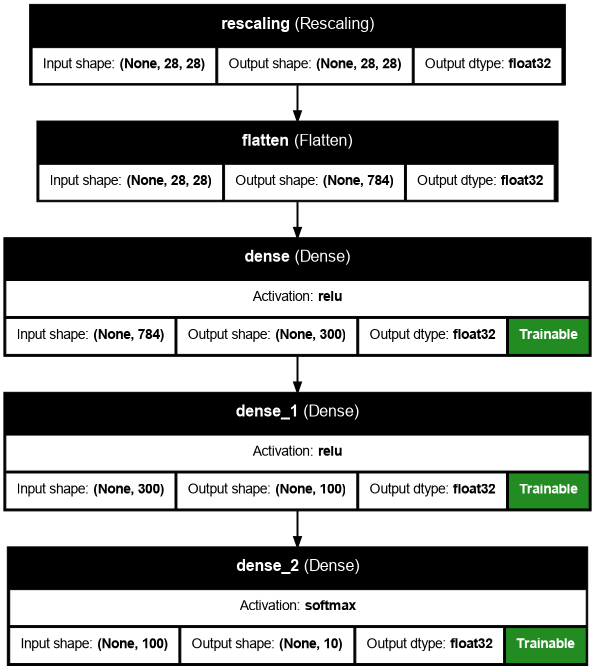

In [23]:
keras.utils.plot_model(
   model,
   to_file="figures/model.png",
   show_shapes=True,
   show_dtype=True,
   show_layer_names=True,
   rankdir="TB",
   expand_nested=True,
   dpi=70,
   show_layer_activations=True,
   show_trainable=True
)

**Accessing the layers, weights and biases programmatically**

- We can print out the layers in the model, including their names.

In [24]:
model.layers

[<Rescaling name=rescaling, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dense name=dense_1, built=True>,
 <Dense name=dense_2, built=True>]

- The third layer (index `2`) is the first `Dense` layer with name `dense`.

In [25]:
hidden1 = model.layers[2]
hidden1.name

'dense'

- We can also get a reference to a layer in the model using the layer's name.

In [26]:
model.get_layer('dense') is hidden1

True

- Calling `get_weights()` on a layer, returns its weights and biases.

In [27]:
weights, biases = hidden1.get_weights()

print(f'weights.shape: {weights.shape}')
print(f'biases.shape: {biases.shape}\n')
print(f'weights:\n{weights}\n')
print(f'biases:\n{biases}')

weights.shape: (784, 300)
biases.shape: (300,)

weights:
[[ 0.03338097  0.0021058   0.03364435 ... -0.07269678 -0.00846653
  -0.00047163]
 [ 0.01571967 -0.06689147 -0.06180093 ... -0.04877541  0.07316099
  -0.06214399]
 [ 0.05423751 -0.05754156 -0.06899983 ...  0.00079244 -0.01735646
   0.0192932 ]
 ...
 [-0.03054434  0.02406701  0.03491599 ... -0.03263281 -0.04479424
   0.03501706]
 [-0.01527715  0.0152663  -0.06074639 ... -0.01023137  0.02592564
   0.0536391 ]
 [-0.04855145  0.06937377  0.00270222 ...  0.06067112  0.02691665
   0.06451246]]

biases:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 

**Compiling a model**

- Once a model has been assembled, it is compiled in order to add an **optimizer**, **loss function** and any desired **metrics**:
  - The **optimizer** is responsible for adjusting the weights in the network during training (after receiving backpropagated gradients).
  - The **loss function** is responsible for taking the output from the network and the target labels, and computing the error (loss) between them.
  - The chosen **metrics** depend on the type of problem, e.g. for a classification problem metrics such as accuracy, precision, recall, and f1-score make sense.

In [28]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.sparse_categorical_crossentropy,
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

- This is equivalent to:

In [29]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

**Training a model**

- Calling the `fit()` method on the model will train the model.
  - Here, the first parameter is our traing dataset `train_ds` (which we know contains batches of **features** and **labels**).
  - The second parameter decides the maximum number of epochs (one epoch is when all the traning data has been passed through the network).
  - The third parameter contains a list of Keras Callbacks (see below).
  - The final parameter takes the validation dataset `val_ds` (used to measure the model's generalization ability on the validation set).

- Keras Callbacks are used to provide extra functionality when training a model.
  - An `EarlyStopping` callback will monitor a training metric (`monitor="val_accuracy"`), and halt traning if it doesn't improve, i.e. increase (`mode="max"`), for a number of epochs (`patience=2`).
    - Note that `monitor="val_loss"` with `mode="min"` could also be used.
    - Setting `restore_best_weights=True`, will restore the weights (after stopping the training early) to the value they had during the epoch where the training metric (here `val_accuracy`) had its best value.
  - A `ModelCheckpoint` callback will monitor a training metric (here `val_loss`), and save a checkpoint (here `checkpoint.keras`) to disk.
    - This is done after each epoch, unless `save_best_only=True`, which will only save the checkpoint if the monitored metric is better than in any previous epoch.
  - A `TensorBoard` callback takes an **absolute path** to a folder, and will store statistics (in a binary format called *protobuff*) to that folder during training.
    - At any point, the Tensorboard web server can be started, which will present the statistics in the chosen folder via a UI in a web browser (even live during training).

- These are the bare minimum callbacks you should be using when traing models with Keras. 

In [30]:
checkpoint_dir_path = os.path.join(os.getcwd(), "checkpointdir")
log_dir_path = os.path.join(os.getcwd(), "logdir")

# Let's delete the checkpoint and log directories if they exist
shutil.rmtree(checkpoint_dir_path, ignore_errors=True)
shutil.rmtree(log_dir_path, ignore_errors=True)

callbacks_list = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max", # accuracy should be maximized (as opposed to mode="min")
        patience=2,
        restore_best_weights=True,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir_path, "checkpoint.keras"),
        monitor="val_loss",
        save_best_only=True,
    ),
    keras.callbacks.TensorBoard(
        log_dir=log_dir_path,
    )
]

history = model.fit(train_ds,
                    epochs=30,
                    callbacks=callbacks_list,
                    validation_data=val_ds)

Epoch 1/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2557 - loss: 2.0480 - val_accuracy: 0.2668 - val_loss: 1.9987
Epoch 2/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3165 - loss: 1.9032 - val_accuracy: 0.3052 - val_loss: 1.9246
Epoch 3/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3424 - loss: 1.8407 - val_accuracy: 0.3277 - val_loss: 1.8747
Epoch 4/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3616 - loss: 1.7962 - val_accuracy: 0.3473 - val_loss: 1.8299
Epoch 5/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3745 - loss: 1.7629 - val_accuracy: 0.3430 - val_loss: 1.8478
Epoch 6/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3846 - loss: 1.7351 - val_accuracy: 0.3627 - val_loss: 1.7837
Epoch 7/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3924 - loss: 1.7098 - val_accuracy: 0.3653 - val_loss: 1.7948
Epoch 8/30
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4001 - loss: 1.6856 - 

**Saving and loading a model**

- Use the `save()` and `load_model()` methods to save and load a model.
- Notice the file extension `.keras` used below instead of the file extension `.h5` (`.h5` has been deprecated in favor of the better `.keras` format).
- Saving a model will save the model architecture (including the optimizer, etc.) and the model weights to disk.
- Loading a model will load the model architecture and model weights into the program (which could then e.g. be used to further train the model).
- Note, if a `ModelCheckpoint` callback was used during training, the model will already be saved as a checkpoint (which can also be loaded into the program).

In [31]:
# DON'T USE .h5 ...
# model.save("my_keras_model.h5")
# model = keras.models.load_model("my_keras_model.h5")

# USE .keras ...
model.save("my_keras_model.keras")
model = keras.models.load_model("my_keras_model.keras")

# # You can also load the model from the saved checkpoint ...
# model = keras.models.load_model("checkpoints/checkpoint.keras")


**Plotting the learning curves from model training**

- The `fit()` method returns a `history` dictionary, that includes statistics (e.g. loss and accuracy) from training the model.
- The code below shows how to plot the accuracy and loss for both the training set and the valiation set.
- These so-called *learning curves* contain vital information regarding the health of the network's training.
  - E.g. when the validation loss starts to diverge from the training loss, the model has started overfitting the training set.

In [32]:
print(history.params)
print(history.epoch)

{'verbose': 'auto', 'epochs': 30, 'steps': 1313}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


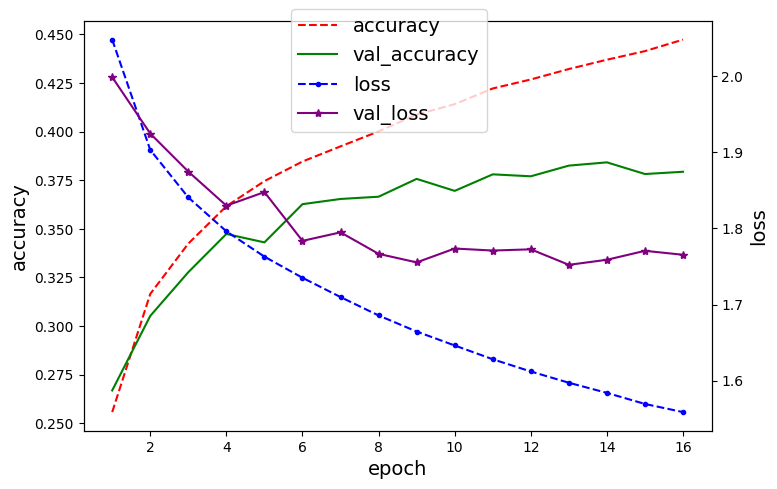

In [33]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.set_xlabel('epoch')
ax1.set_ylabel('accuracy')
ax1.plot(range(1,1+len(accuracy)), accuracy, color='red', linestyle='--', label='accuracy')
ax1.plot(range(1,1+len(val_accuracy)), val_accuracy, color='green', label='val_accuracy')

ax2 = ax1.twinx()
ax2.set_ylabel('loss')
ax2.plot(range(1,1+len(loss)), loss, color='blue', linestyle='--', marker='.', label='loss')
ax2.plot(range(1,1+len(val_loss)), val_loss, color='purple', marker='*', label='val_loss')

fig.legend(loc="upper center")
fig.tight_layout()
save_fig("keras_learning_curves_plot (alternative 1)")

- We can also use a Pandas Dataframe to plot the learning curves.

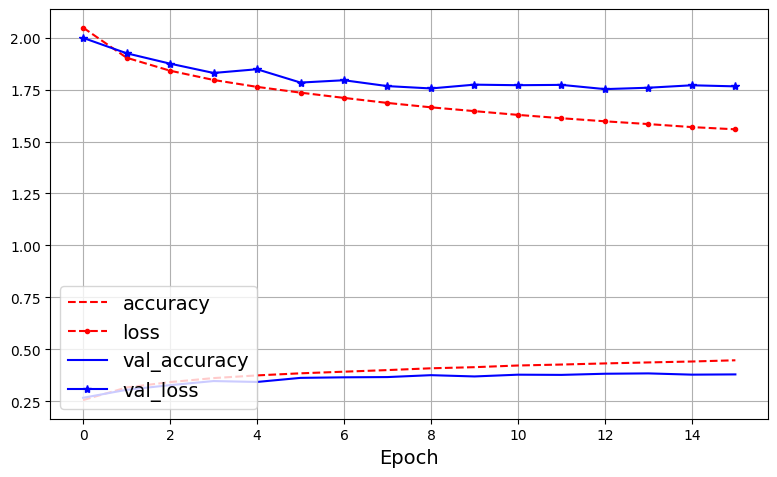

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    grid=True,
    xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"])
plt.legend(loc="lower left")
save_fig("keras_learning_curves_plot (alternative 2)")

**Evaluating a model**

- Once a model has been trained, we can run the test dataset through it to obtain evaluation statistics (loss, accuracy, etc.), which estimate the model's generalization to previously unseen data.
- Notice that the `evaluate()` method is run on the test dataset, and returns the metrics (in this case `loss` and `accuracy`).

In [35]:
model.evaluate(test_ds, verbose=2)

375/375 - 1s - 2ms/step - accuracy: 0.3778 - loss: 1.7709


[1.7709169387817383, 0.3777500092983246]

**Using a model to make predictions (inference)**

- Now the model can be used for classifying new samples.
- This is done by calling the `predict()` method.
- Since this is a classification model, it will return the probability associated with each class (10 probabilities for the 10-class problem).

In [36]:
y_proba = model.predict(test_ds)
y_proba.round(2)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step


array([[0.02, 0.02, 0.02, ..., 0.36, 0.01, 0.01],
       [0.02, 0.06, 0.03, ..., 0.11, 0.01, 0.38],
       [0.01, 0.  , 0.2 , ..., 0.21, 0.  , 0.01],
       ...,
       [0.19, 0.  , 0.31, ..., 0.08, 0.01, 0.  ],
       [0.05, 0.07, 0.09, ..., 0.14, 0.11, 0.14],
       [0.15, 0.  , 0.26, ..., 0.15, 0.01, 0.02]],
      shape=(12000, 10), dtype=float32)

**Getting the class with the highest probability**

- Numpy's `argmax()` method will return the element index with the highest value in an array.

In [37]:
y_pred = y_proba.argmax(axis=-1)
y_pred

array([7, 9, 5, ..., 2, 4, 2], shape=(12000,))

- Once the class index (with the highest probability) is known, it can be used to index into the list of class names.
- This returns the name of the class the model predicted the input image to belong to.

In [38]:
np.array(class_names)[y_pred]

array(['horse', 'truck', 'dog', ..., 'bird', 'deer', 'bird'],
      shape=(12000,), dtype='<U10')

- Let's plot some images together with their predictions
  - The predicted class is in the title.
  - The actual class is within parentheses.
- Notice that this model (with the current hyperparameter settings) isn't a poor model (there is room for improvement).
  - Actually, if we had used Convolutitional Layers for the hidden layers, and a Dense layer for the output layer, we would have obtained a much better model.
  - But we will not be using Convolutitional Layers in this notebook.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


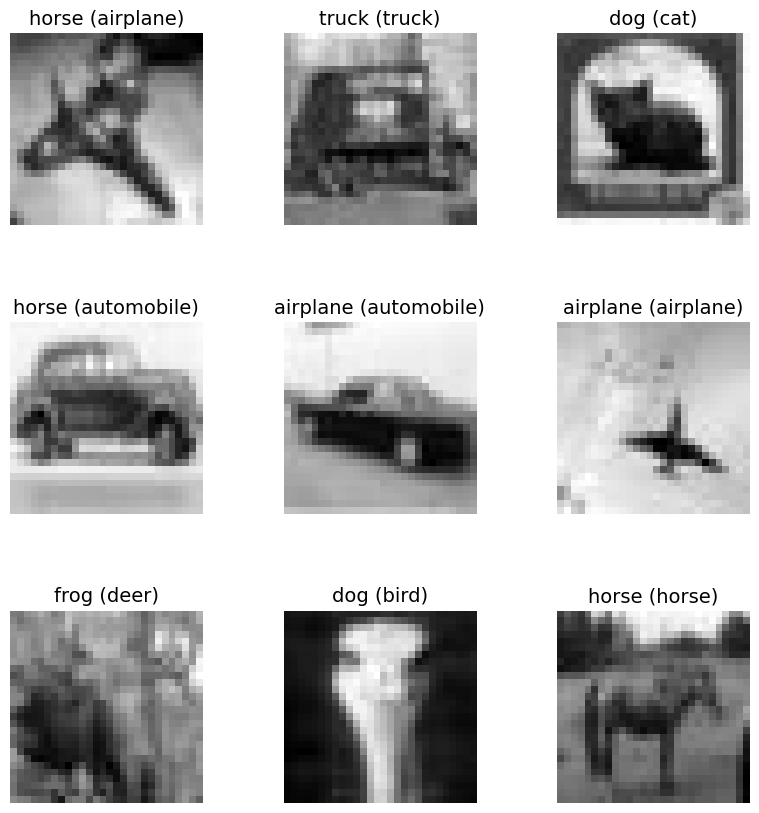

In [39]:
plt.figure(figsize=(10, 10))
for image_batch, label_batch in test_ds.take(1):
    for i, (image_tensor, label_tensor) in enumerate(zip(image_batch, label_batch)):
        image = image_tensor.numpy().reshape(1,28,28,1)
        label = label_tensor.numpy()
        pred_idx = model.predict(image).argmax(axis=-1)
        pred_classname = np.array(class_names)[pred_idx][0]
        actual_classname = np.array(class_names)[label]
        image = image_tensor.numpy().reshape(28,28)
        
        plt.subplot(3, 3, i+1)
        plt.imshow(image, cmap="grey", interpolation="nearest")
        plt.axis('off')
        plt.title(f'{pred_classname} ({actual_classname})')
        
        if i == 8: break
plt.subplots_adjust(wspace=0.2, hspace=0.5)
save_fig('sample_of_predicted_images_during_inference', tight_layout=False)

**Visualization with TensorBoard**

- If we used a `TensorBoard` callback during training (which we did), the TensorBoard web sever can be started to view training statistics.
  - The TensorBoard web sever can even be started before training to view live updates during training.
- When starting the web server, pass in the **absolute path** to the Tensorboard log directory, and an optional port number (default `6006`).
- Then open a web browser to visualize the TensorBoard training statistics in TensorBoard's Web UI.
- The code below displays the Web UI directly in the notebook.
- If you are using the notebook in VSCode, you can also start TensorBoard via the Command Palette:
  - Windows/Linux: `Ctrl` + `Shift` + `P`, then choose `Python: Launch TensorBoard`
  - MacOS: `Command` + `Shift` + `P`, then choose `Python: Launch TensorBoard`
- If the TensorBoard UI doesn't show in the notebook cell:
  - Try running the notebook cell again.
  - Or, change the port number and run the notebook cell again.
  - Or, open a web browser and visit http://localhost:`<port>` (where `<port>` is your chosen port number, e.g. http://localhost:6010)
  - Or, if using VSCode, start TensorBoard via the Command Palette.

In [40]:
%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir "{log_dir_path}" --port=6010

Reusing TensorBoard on port 6010 (pid 254701), started 7:20:21 ago. (Use '!kill 254701' to kill it.)

---
## 5. Fine-Tuning Neural Network Hyperparameters with Keras Tuner

[Keras Tuner](https://keras.io/keras_tuner) is a hyperparameter optimization framework that can be used to automate the process of searching for optimal hyperparameters.

Let's start by clearing the Keras session and setting a random seed.

In [41]:
# Reset the name counters Keras uses to name the layers
tf.keras.backend.clear_session()

# Set a random seed to ensure the same pseudorandom number sequence
tf.random.set_seed(42)

**Create a *Build Model* Function**

[Keras Tuner](https://keras.io/keras_tuner) has a number of classes that implement various *search strategies* in searching for optimal hyperparameters, e.g.:
- [RandomSearch](https://keras.io/keras_tuner/api/tuners/random/#randomsearch-class)
- [Hyperband](https://keras.io/keras_tuner/api/tuners/hyperband/#hyperband-class)
- [BayesianOptimization](https://keras.io/keras_tuner/api/tuners/bayesian/#bayesianoptimization-class)

These classes all expect a [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class) as the first argument to their constructors.
- A [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class) is either:
  - A function that accepts a [HyperParameters](https://keras.io/keras_tuner/api/hyperparameters) object `hp` as its first argument, and creates and returns a Keras model.
    - The [HyperParameters](https://keras.io/keras_tuner/api/hyperparameters) object `hp` is used to define the hyperparameters during model creation:
      - `hp.Int()` selects an integer between a specified `min_value` and `max_value`.
      - `hp.Float()` selects a float between a specified `min_value` and `max_value`.
      - `hp.Choice()` selects a value from a set of `values`.
  - A class that derives from [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class) and implements a `build()` method with the same functionality as the function described above.

The code below creates a function that:
1. Defines a number tunable hyperparameters:
   - `n_hidden` is the number of hidden layers (an `int` between a `min_value` and a `max_value`).
   - `n_neurons` is the number of neurons in each hidden layer (an `int` between a `min_value` and a `max_value`).
   - `learning_rate` is the learning rate to use during training (a `float` between a `min_value` and a `max_value`).
   - `optimizer` is the name of the optimizer to use during training (a string value from a set of `values`).
2. Builds a model using the chosen hyperparameters.
3. Compiles the model.
4. Returns the model.

In [42]:
def build_model(hp):
    # Let Keras Tuner choose the hyperparameters
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Build a model using the chosen hyperparameters
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=image_size))
    # model.add(keras.layers.Reshape(image_size))
    model.add(keras.layers.Rescaling(1./255))    
    model.add(keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(num_classes, activation="softmax"))

    # Compile the model using the chosen hyperparameters
    model.compile(optimizer=optimizer,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    
    # Return the model
    return model

**Perform a random search using the [RandomSearch](https://keras.io/keras_tuner/api/tuners/random/#randomsearch-class) class**

The constructor has the following parameters:
- `build_model` is the function we defined above.
- `objective` is the metric the Keras Tuner is trying to optimize.
- `max_trials` is the number of times the random search is performed (using a different sample of hyperparameters during each trial).
- `overwrite` with a value of `True` will delete and recreate the folder `directory/project_name` if it already exists (see below).
- `directory` is the name of the folder on disk where Keras Tuner stores information about a trial.
- `project_name` is the name of the subfolder (under `directory`) where Keras Tuner stores information about a trial.
- `seed` is the seed number to use for the pseudo-random number generator.

The `search()` method has the following parameters:
- `train_ds` (first argument) is the training dataset.
- `epochs` is the max number of epochs to train the model.
- `validation_data` is the validation dataset.

In [43]:
random_search_tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    overwrite=True,
    directory="keras_tuner",
    project_name="rnd_search",
    seed=42)

random_search_tuner.search(train_ds,
                           epochs=10,
                           validation_data=(val_ds))

Trial 5 Complete [00h 00m 17s]
val_accuracy: 0.19583334028720856

Best val_accuracy So Far: 0.31583333015441895
Total elapsed time: 00h 01m 29s


**Get the best model**

- Calling the `get_best_models()` function on the Keras Tuner instance returns the top `n` models.
- The model with index `0` is the best model.

In [44]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0] # best model

**Get the best set of hyperparameters**

- Calling the `get_best_hyperparameters()` function on the Keras Tuner instance returns the top `n` set of hyperparametes.
- The set with index `0` is the best set of hyperparameters.

In [45]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values  # best hyperparameter values

{'n_hidden': 8,
 'n_neurons': 37,
 'learning_rate': 0.008547485565344062,
 'optimizer': 'sgd'}

**Get the best trial**

- Calling the `get_best_trials()` function on the Keras Tuner instance returns the top `n` trials.
- The trial with index `0` is the best trial.
- Calling the `summary()` function on a trial instance returns summary information for that trial.
  - `Score` is the value of the `objective`'s metric (`val_accuracy` in this case).

In [46]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 3 summary
Hyperparameters:
n_hidden: 8
n_neurons: 37
learning_rate: 0.008547485565344062
optimizer: sgd
Score: 0.31583333015441895


**Get a trial's metrics**

- Calling the `get_last_value()` function on a trial instance's `metrics` property returns the value of the chosen metric (`val_accuracy` in this case).

In [47]:
best_trial.metrics.get_last_value("val_accuracy")

np.float64(0.31583333015441895)

**(Re-)training and (re)-evaluating the Best Model**

- Once the best model model has been obtained, it can be re-trained, e.g. on the full dataset (training set + validation set), and re-evaluated on the test set.

In [48]:
best_model.fit(train_ds, epochs=10)
test_loss, test_accuracy = best_model.evaluate(test_ds)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3120 - loss: 1.8732
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3201 - loss: 1.8538
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3285 - loss: 1.8369
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3329 - loss: 1.8217
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3372 - loss: 1.8091
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3425 - loss: 1.7976
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3487 - loss: 1.7854
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3539 - loss: 1.7741
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3580 - loss: 1.7639
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3611 - loss: 1.7541
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.3450 - loss: 1.8067


**Deriving from [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class)**

We can also create a custom hyperparameter class by deriving from [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class) and defining a `build()` method.
- Here we are reusing our `build_model()` function inside the `build()` method.
- We are also defining a `fit()` method to fit the model on a dataset.

In [49]:
class MyClassificationHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, ds, **kwargs):
        return model.fit(ds, **kwargs)

**Perform a hyperband search using the [Hyperband](https://keras.io/keras_tuner/api/tuners/hyperband/#hyperband-class) class**

The constructor has the following parameters:
- `MyClassificationHyperModel()` is an instance of our custom [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class) class.
- `objective` is the metric the Keras Tuner is trying to optimize.
- `max_epochs` is the maximum number of epochs to train a model during a trial.
- `factor` is the reduction factor for the number of epochs and number of models for each bracket.
- `hyperband_iterations` is the number of times to iterate over the full Hyperband algorithm.
- `overwrite` with a value of `True` will delete and recreate the folder `directory/project_name` if it already exists (see below).
- `directory` is the name of the folder on disk where Keras Tuner stores information about a trial.
- `project_name` is the name of the subfolder (under `directory`) where Keras Tuner stores information about a trial.
- `seed` is the seed number to use for the pseudo-random number generator.

The `search()` method has the following parameters:
- `train_ds` (first argument) is the training dataset.
- `epochs` is the max number of epochs to train the model.
- `validation_data` is the validation dataset.
- `callbacks` is the list of callbacks to use (here the EarlyStopping and TensorBoard callbacks are used).

In [50]:
hyperband_tuner = kt.Hyperband(
    MyClassificationHyperModel(),
    objective="val_accuracy",
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    overwrite=True,
    directory="keras_tuner",
    project_name="hyperband",
    seed=42)

root_logdir = os.path.join(Path(hyperband_tuner.project_dir), "tensorboard")
tensorboard_cb = tf.keras.callbacks.TensorBoard(root_logdir)
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=2)

hyperband_tuner.search(train_ds,
                       epochs=10,
                       validation_data=(val_ds),
                       callbacks=[early_stopping_cb, tensorboard_cb])

Trial 60 Complete [00h 00m 09s]
val_accuracy: 0.2606666684150696

Best val_accuracy So Far: 0.39383333921432495
Total elapsed time: 00h 09m 56s


**Get the best model, and re-train and re-evaluate it**

In [51]:
best_model = hyperband_tuner.get_best_models(num_models=1)[0]
best_model.fit(train_ds, epochs=10)
test_loss, test_accuracy = best_model.evaluate(test_ds)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4312 - loss: 1.6072
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4376 - loss: 1.5901
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4436 - loss: 1.5743
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4498 - loss: 1.5587
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4530 - loss: 1.5440
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4575 - loss: 1.5309
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4637 - loss: 1.5176
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4674 - loss: 1.5048
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4712 - loss: 1.4928
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4745 - loss: 1.4814
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.4038 - loss: 1.7079


**Perform a Bayesian Optimization search using the [BayesianOptimization](https://keras.io/keras_tuner/api/tuners/bayesian/#bayesianoptimization-class) class**

The constructor has the following parameters:
- `MyClassificationHyperModel()` is an instance of our custom [HyperModel](https://keras.io/keras_tuner/api/hypermodels/base_hypermodel/#hypermodel-class) class.
- `objective` is the metric the Keras Tuner is trying to optimize.
- `max_trials` is the number of times the random search is performed (using a different sample of hyperparameters during each trial).
- `alpha` is the value added to the diagonal of the kernel matrix during fitting.
- `beta` is the balancing factor of exploration and exploitation.
- `overwrite` with a value of `True` will delete and recreate the folder `directory/project_name` if it already exists (see below).
- `directory` is the name of the folder on disk where Keras Tuner stores information about a trial.
- `project_name` is the name of the subfolder (under `directory`) where Keras Tuner stores information about a trial.
- `seed` is the seed number to use for the pseudo-random number generator.

The `search()` method has the following parameters:
- `train_ds` (first argument) is the training dataset.
- `epochs` is the max number of epochs to train the model.
- `validation_data` is the validation dataset.
- `callbacks` is the list of callbacks to use (here the EarlyStopping callback is used).

In [52]:
bayesian_opt_tuner = kt.BayesianOptimization(
    MyClassificationHyperModel(),
    objective="val_accuracy",
    max_trials=10,
    alpha=1e-4,
    beta=2.6,
    overwrite=True,
    directory="keras_tuner",
    project_name="bayesian_opt",
    seed=42)

bayesian_opt_tuner.search(train_ds,
                          epochs=10,
                          validation_data=(val_ds),
                          callbacks=[early_stopping_cb])

Trial 10 Complete [00h 00m 21s]
val_accuracy: 0.36899998784065247

Best val_accuracy So Far: 0.38350000977516174
Total elapsed time: 00h 03m 11s


**Get the best model, and re-train and re-evaluate it**

In [53]:
best_model = bayesian_opt_tuner.get_best_models(num_models=1)[0]
best_model.fit(train_ds, epochs=10)
test_loss, test_accuracy = best_model.evaluate(test_ds)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4267 - loss: 1.5993
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4374 - loss: 1.5745
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4446 - loss: 1.5528
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4554 - loss: 1.5324
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4591 - loss: 1.5124
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4637 - loss: 1.4962
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4708 - loss: 1.4753
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4774 - loss: 1.4600
Epoch 9/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4851 - loss: 1.4353
Epoch 10/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4920 - loss: 1.4188
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3670 - loss: 1.8867


**Load TensorBoard**

In [63]:
%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir "{root_logdir}" --port=6012

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6012 (pid 742811), started 0:00:07 ago. (Use '!kill 742811' to kill it.)

---
## 6. Building, Training, and Evaluating a Regression Model Using the Sequential API

Building, training, and evaluating a regression model, is done exactly the same way as a classification model (and can use callbacks, the Keras Tuner, etc.).

The only major difference is the output layer's activation function and loss function.
- A regression model's output layer usually doesn't have an activation function (instead of a softmax activation function), since the output is real numbers instead of classes.
- A regression model's loss function is usually the Mean Squared Error (MSE) function (instead of a Cross Entropy Loss function).

Let's look at a quick example using the California Housing Dataset.

**Load, split and scale the California housing dataset**
- Features:
  - **MedInc** is the median income of households in the block group (in tens of thousands of USD)
  - **HouseAge** is the median age of houses in the block group (years)
  - **AveRooms** is the average number of rooms per household
  - **AveBedrms** is the average number of bedrooms per household
  - **Population** is the total population in the block group
  - **AveOccup** is the average number of occupants per household
  - **Latitude** is the latitude of the block group (geographic location)
  - **Longitude** is the longitude of the block group (geographic location)
- Target:
  - **MedHouseVal** is the median house value for households in the block group, measured in hundreds of thousands of USD, capped at 5.0 (≈ $500,000)

The objective is to predict the target **MedHouseVal** using the features.

In [55]:
# Load and split the California housing dataset
housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

print(f'X_train.shape: {X_train.shape}')
print(f'y_train.shape: {y_train.shape}\n')

print(f'X_valid.shape: {X_valid.shape}')
print(f'y_valid.shape: {y_valid.shape}\n')

print(f'X_test.shape: {X_test.shape}')
print(f'y_test.shape: {y_test.shape}')

X_train.shape: (11610, 8)
y_train.shape: (11610,)

X_valid.shape: (3870, 8)
y_valid.shape: (3870,)

X_test.shape: (5160, 8)
y_test.shape: (5160,)


**Display the training set features in a Pandas DataFrame**

In [56]:
df_X_train = pd.DataFrame(data=X_train, columns=housing.feature_names)
df_X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,3.5214,15.0,3.049945,1.106548,1447.0,1.605993,37.63,-122.43
1,5.3275,5.0,6.490060,0.991054,3464.0,3.443340,33.69,-117.39
2,3.1000,29.0,7.542373,1.591525,1328.0,2.250847,38.44,-122.98
3,7.1736,12.0,6.289003,0.997442,1054.0,2.695652,33.55,-117.70
4,2.0549,13.0,5.312457,1.085092,3297.0,2.244384,33.93,-116.93


**Display the training set target in a Pandas DataFrame**

In [57]:
df_y_train = pd.DataFrame(data=y_train, columns=housing.target_names)
df_y_train.head()

,MedHouseVal
0,1.442
1,1.687
2,1.621
3,2.621
4,0.956


**Create a regression model**

In [58]:
tf.random.set_seed(42)

norm_layer = tf.keras.layers.Normalization(input_shape=X_train.shape[1:])

model = tf.keras.Sequential([
    norm_layer,
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])

**Train the model**

In [59]:
norm_layer.adapt(X_train)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.8931 - loss: 0.7976 - val_RootMeanSquaredError: 0.7442 - val_loss: 0.5538
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6124 - loss: 0.3751 - val_RootMeanSquaredError: 0.5847 - val_loss: 0.3419
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5920 - loss: 0.3505 - val_RootMeanSquaredError: 0.6962 - val_loss: 0.4846
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5789 - loss: 0.3352 - val_RootMeanSquaredError: 0.6622 - val_loss: 0.4385
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 994us/step - RootMeanSquaredError: 0.5754 - loss: 0.3311 - val_RootMeanSquaredError: 0.7581 - val_loss: 0.5747
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5631 - loss: 0.3171 - val_RootMeanSquaredError: 1.0491 - val_loss: 1.1007
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5665 - l

**Evaluate the model**

In [60]:
loss_test, rmse_test = model.evaluate(X_test, y_test)

print(f'\nloss_test: {loss_test}')
print(f'rmse_test: {rmse_test}')

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - RootMeanSquaredError: 0.5377 - loss: 0.2891

loss_test: 0.28911998867988586
rmse_test: 0.5376988053321838


**Predict three *new* samples**

In [61]:
X_new = X_test[:3]
y_pred = model.predict(X_new)

print(f'\ny_pred:\n{y_pred}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

y_pred:
[[0.5049446]
 [1.2779728]
 [4.868819 ]]
